In [1]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2

# plot matplots nicely
%matplotlib inline  

In [2]:
from stericheight.data_handler import *
from stericheight.steric_height import *
from stericheight.plotting_fns import PlottingFns
from stericheight.utils import Utils
from load_meop import MEOP
from region import Region
from composite import Composite
pfns = PlottingFns()

In [3]:
import gsw
import cmocean
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.optimize import root_scalar


ARGO = '/nfs/b0133/eejco/data/ARGO/DataSelection_a0ad0869-68c3-4b7d-af4c-9c010ab6e378/'

In [4]:
sla = SLA(deg=0.25).da
sice = xr.open_dataset('../data/NSIDC/sice_processed.nc')
sice = sice.__xarray_dataarray_variable__
elevation_ = GEBCO(coarsen_factor=40).ds.elevation


In [5]:
def sanom(da):
    return da.groupby('time.month') - da.groupby('time.month').mean()

In [6]:
extent =[100,160,-69,-62]
extent_mertz =[138.5,143,-67,-62]
extent_vcbay = [106,114,-70,-65.2]
extent_voyeykov = [121,128,-70,-65.4]
elevation = elevation_.sel(latitude = slice(extent[2], extent[3]), longitude = slice(extent[0],extent[1]))


<GeoAxes: xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>

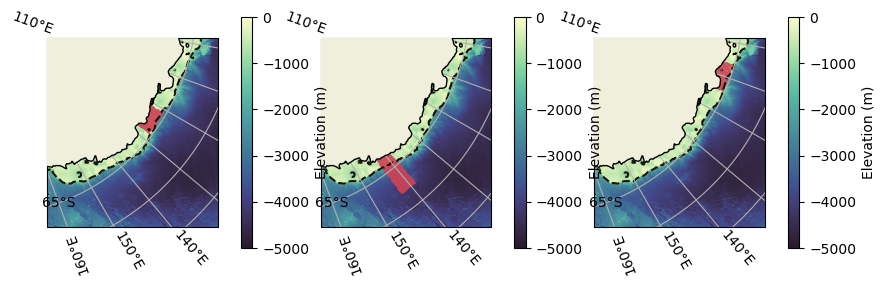

In [7]:
shelf = Region('EA Shelf',extent,elevation_,min_elevation=-1000)
voyeykov = Region('Voyeykov',extent_voyeykov)
mertz = Region('Mertz',extent_mertz)
vcbay = Region('Vincennes Bay',extent_vcbay)
fig, ax = plt.subplots(1,3,figsize=(10,3),subplot_kw={'projection':ccrs.SouthPolarStereo()})
voyeykov.plot_region(ax=ax[0],extent=extent)
mertz.plot_region(ax=ax[1],extent=extent)
vcbay.plot_region(ax=ax[2],extent=extent)

In [8]:
meop_mertz=MEOP(extent=extent_mertz)
df1=meop_mertz.load_profiles()

100%|██████████| 82/82 [01:18<00:00,  1.04it/s]


In [ ]:
#find seals which travel a decent (>1 degree) meridional distance 
longg = df1.groupby('platform').latitude.max().index[(df1.groupby('platform').latitude.max()-df1.groupby('platform').latitude.min())>1]
df1 = df1[(df1.index > pd.Timestamp(2019,11,1)) & (df1.index < pd.Timestamp(2020,1,31))]

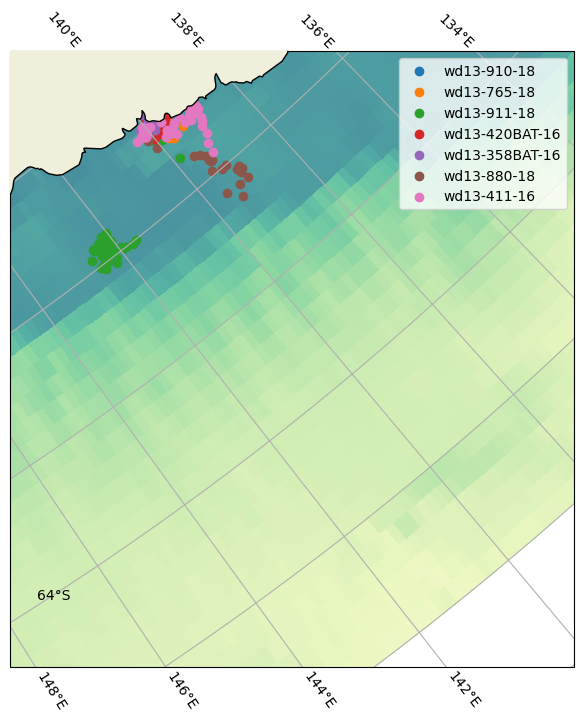

In [10]:
fig,ax=plt.subplots(figsize=(10,8),subplot_kw={'projection':ccrs.SouthPolarStereo()})
pfns.sp(ax,elevation,extent=extent_mertz,cmap=cmocean.cm.deep,land_zorder=3)
for platform in df1.platform.unique():
    dff = df1[df1.platform == platform]
    ax.scatter(dff.longitude,dff.latitude,transform=ccrs.PlateCarree(),label=platform)
ax.legend()

In [11]:
df11=df1[df1.platform=='wd13-880-18']
wd13_temp, wd13_psal, wd13_df = meop_mertz.reindex_profiles(df11)

In [12]:
wd13_temp

<xarray.DataArray 'TEMP_ADJUSTED' (time: 30, pressure: 54)> Size: 6kB
array([[-1.9619809, -1.9623083, -1.9626355, ..., -1.9660879, -1.9610301,
        -1.9599842],
       [-1.9149622, -1.913579 , -1.9121958, ..., -1.9670104, -1.966055 ,
        -1.9649998],
       [-1.948    , -1.948    , -1.948    , ...,        nan,        nan,
               nan],
       ...,
       [-1.8682232, -1.8682572, -1.868291 , ..., -1.5137491, -1.1144125,
               nan],
       [-1.8724626, -1.8725104, -1.8725581, ..., -1.5065039, -1.2557912,
               nan],
       [-1.8903917, -1.8904412, -1.8904908, ..., -1.5090368, -1.2772291,
               nan]], dtype=float32)
Coordinates:
  * pressure  (pressure) float32 216B 4.0 6.0 8.0 10.0 ... 200.0 300.0 400.0
  * time      (time) datetime64[ns] 240B 2019-11-21T14:29:59 ... 2019-12-07T2...
Attributes:
    long_name:  SEA TEMPERATURE IN SITU ITS-90 SCALE
    units:      degree_Celsius
    valid_min:  -2.0
    valid_max:  40.0
    comment:    In situ measurement

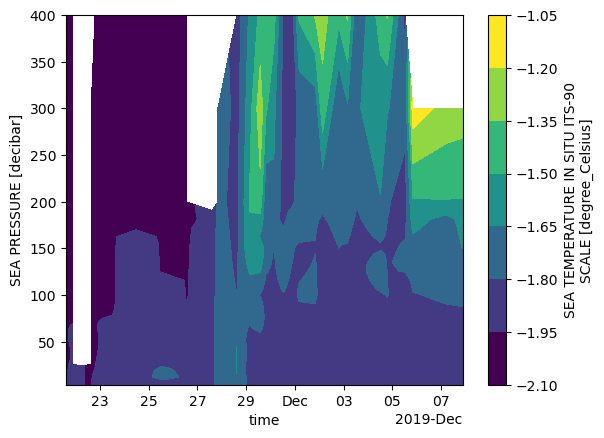

In [13]:
wd13_temp.plot.contourf(x='time',y='pressure')

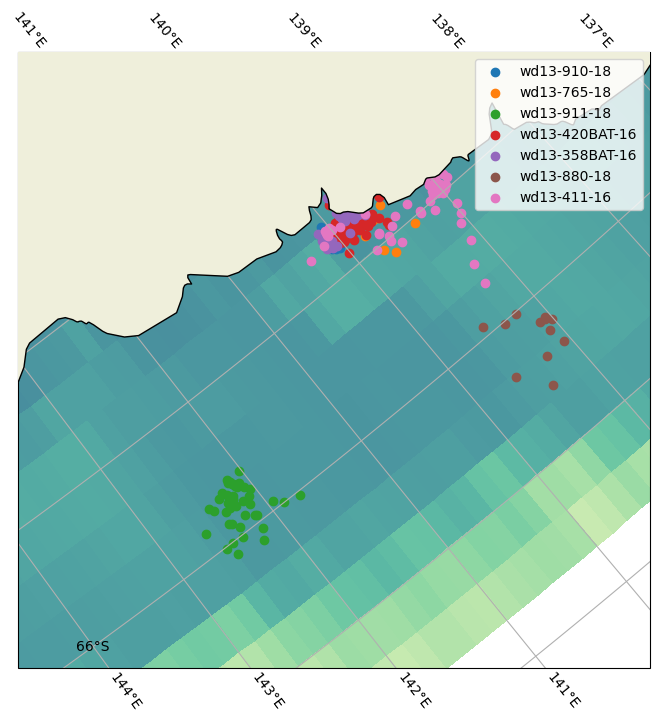

In [30]:
fig,ax=plt.subplots(figsize=(10,8),subplot_kw={'projection':ccrs.SouthPolarStereo()})
pfns.sp(ax,elevation,extent=extent_mertz,cmap=cmocean.cm.deep,land_zorder=3)
for platform in df1_dec19.platform.unique():
    dff = df1_dec19[df1_dec19.platform == platform]
    ax.scatter(dff.longitude,dff.latitude,transform=ccrs.PlateCarree(),label=platform)
ax.legend()


In [ ]:
month = 12
# plot all seal trails for